## MINI PROJECT MACHINE LEARNING 
--- 
### REGRESI: Peramalan (Forecasting) Beban Puncak Konsumsi Energi Listrik Berdasarkan Pola Cuaca Historis
**Nama :** Yayan Gisna Yudati

**Nim :** F1G123055

**Prodi/Jurusan:** Ilmu Komputer/FMIPA

**Dataset:** Hourly energy demand generation and weather

---
### 1. Data Understanding
**Sumber Dataset:** Dataset ini menggabungkan dua sumber data historis (2015-2018), yaitu data konsumsi beban listrik (Energi) dan data kondisi cuaca (Weather).

**Tujuan:** Memprediksi `total load actual` (konsumsi beban listrik sebenarnya) menggunakan data masa lalu dan data cuaca 6 jam sebelumnya.

In [ ]:
# ==========================================
# IMPORT LIBRARIES & SETUP ENVIRONMENT
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import ast
import joblib
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("Modul dan Library berhasil dimuat.")

Modul dan Library berhasil dimuat.


c:\Users\US3R\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==========================================
# LOAD DATA 
# ==========================================
df_energy = pd.read_csv('energy_dataset_train.csv')
df_weather = pd.read_csv('weather_features.csv')

df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True).dt.tz_localize(None)
df_weather['time'] = pd.to_datetime(df_weather['time'], utc=True).dt.tz_localize(None)

In [ ]:
print("\n=== SAMPEL DATA ENERGI ===")
df_energy.head()


=== SAMPEL DATA TERATAS ===


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2014-12-31 23:00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,863.0,1051.0,1899.0,0.0,7096.0,43.0,73.0,49.0,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,920.0,1009.0,1658.0,0.0,7096.0,43.0,71.0,50.0,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,1164.0,973.0,1371.0,0.0,7099.0,43.0,73.0,50.0,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,NaN,1503.0,949.0,779.0,0.0,7098.0,43.0,75.0,50.0,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,NaN,1826.0,953.0,720.0,0.0,7097.0,43.0,74.0,42.0,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [40]:
print("\n=== SAMPEL DATA CLIMATE ===")
df_weather.head()


=== SAMPEL DATA CLIMATE ===


,time,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all,weather_main
0,2015-01-01 00:00:00,272.491463,1016.4,82.4,2.0,135.2,0.0,0.0,clear
1,2015-01-01 01:00:00,272.512700,1016.2,82.4,2.0,135.8,0.0,0.0,clear
2,2015-01-01 02:00:00,272.099137,1016.8,82.0,2.4,119.0,0.0,0.0,clear
3,2015-01-01 03:00:00,272.089469,1016.6,82.0,2.4,119.2,0.0,0.0,clear
4,2015-01-01 04:00:00,272.145900,1016.6,82.0,2.4,118.4,0.0,0.0,clear


In [41]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================
print("=== INFORMASI DATASET ENERGI ===")
df_energy.info()

=== INFORMASI DATASET ENERGI ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32064 entries, 0 to 32063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   time                                         32064 non-null  datetime64[ns]
 1   generation biomass                           32045 non-null  float64       
 2   generation fossil brown coal/lignite         32046 non-null  float64       
 3   generation fossil coal-derived gas           32046 non-null  float64       
 4   generation fossil gas                        32046 non-null  float64       
 5   generation fossil hard coal                  32046 non-null  float64       
 6   generation fossil oil                        32045 non-null  float64       
 7   generation fossil oil shale                  32046 non-null  float64       
 8   generation fossil peat                     

In [42]:
# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================
print("=== INFORMASI DATASET CLIMATE ===")
df_weather.info()

=== INFORMASI DATASET CLIMATE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32060 entries, 0 to 32059
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   time          32060 non-null  datetime64[ns]
 1   temp          32060 non-null  float64       
 2   pressure      32060 non-null  float64       
 3   humidity      32060 non-null  float64       
 4   wind_speed    32060 non-null  float64       
 5   wind_deg      32060 non-null  float64       
 6   rain_1h       32060 non-null  float64       
 7   clouds_all    32060 non-null  float64       
 8   weather_main  32060 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(1)
memory usage: 2.2+ MB


In [43]:
print("\n=== STATISTIK DESKRIPTIF ENERGI ===")
df_energy.describe()


=== STATISTIK DESKRIPTIF ENERGI ===


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,generation hydro pumped storage consumption,generation hydro run-of-river and poundage,generation hydro water reservoir,generation marine,generation nuclear,generation other,generation other renewable,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,32064,32045.000000,32046.000000,32046.0,32046.000000,32046.000000,32045.000000,32046.0,32046.0,32046.0,0.0,32045.000000,32045.000000,32046.000000,32045.0,32047.000000,32046.000000,32046.000000,32046.000000,32045.000000,32046.0,32046.000000,32064.000000,0.0,32064.000000,32064.000000,32028.000000,32064.000000,32064.000000
mean,2016-10-29 22:30:00,388.083570,448.606347,0.0,5553.286058,4263.943581,299.779248,0.0,0.0,0.0,NaN,487.098018,963.882540,2618.500874,0.0,6277.505508,60.611777,84.498502,1466.173563,266.615197,0.0,5455.380984,1471.226828,NaN,5458.846713,28691.639471,28671.907300,48.745893,56.720266
min,2014-12-31 23:00:00,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,2015-11-30 22:45:00,336.000000,0.000000,0.0,4094.000000,2470.000000,264.000000,0.0,0.0,0.0,NaN,0.000000,627.000000,1058.000000,0.0,5865.000000,53.000000,72.000000,80.000000,236.000000,0.0,2940.000000,79.000000,NaN,2978.000000,24782.000000,24796.000000,40.600000,48.450000
50%,2016-10-29 22:30:00,370.000000,507.000000,0.0,4907.000000,4464.500000,301.000000,0.0,0.0,0.0,NaN,79.000000,893.000000,2170.000000,0.0,6617.000000,57.000000,86.000000,633.000000,276.000000,0.0,4830.000000,592.000000,NaN,4829.000000,28889.000000,28880.500000,49.650000,56.990000
75%,2017-09-28 22:15:00,456.000000,794.000000,0.0,6295.000000,5890.000000,331.000000,0.0,0.0,0.0,NaN,647.000000,1245.000000,3799.000000,0.0,7039.000000,82.000000,96.000000,2667.750000,308.000000,0.0,7379.750000,2713.000000,NaN,7341.000000,32205.000000,32129.250000,59.180000,66.350000
max,2018-08-28 22:00:00,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,4523.000000,2000.000000,9477.000000,0.0,7117.000000,106.000000,118.000000,5792.000000,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000
std,NaN,87.035825,360.513350,0.0,2188.678481,1993.066457,53.090690,0.0,0.0,0.0,NaN,798.046256,402.390713,1861.434951,0.0,837.428145,20.880342,13.999649,1695.188927,50.961178,0.0,3206.584837,1693.827187,NaN,3175.335805,4588.394032,4567.440757,14.382858,14.046621


In [44]:
print("\n=== STATISTIK DESKRIPTIF CLIMATE ===")
df_weather.describe()


=== STATISTIK DESKRIPTIF CLIMATE ===


,time,temp,pressure,humidity,wind_speed,wind_deg,rain_1h,clouds_all
count,32060,32060.000000,32060.000000,32060.000000,32060.000000,32060.000000,32060.000000,32060.000000
mean,2016-10-29 23:36:16.169682176,289.773407,1016.026560,67.680649,2.482748,166.876117,0.075108,24.591054
min,2015-01-01 00:00:00,271.941863,974.600000,26.400000,0.000000,0.000000,0.000000,0.000000
25%,2015-11-30 23:45:00,284.098000,1012.600000,56.200000,1.400000,126.650000,0.000000,12.000000
50%,2016-10-29 23:30:00,289.143916,1016.800000,69.200000,2.200000,166.600000,0.000000,22.000000
75%,2017-09-28 23:15:00,295.212500,1020.600000,79.600000,3.200000,208.000000,0.060000,35.000000
max,2018-08-28 23:00:00,309.266000,1039.800000,100.000000,29.800000,338.000000,4.150000,92.000000
std,NaN,7.324147,8.360809,14.854193,1.385629,57.620472,0.207915,17.306280


### 2. Data Preprocessing
Pada tahap ini dilakukan:
1.  **Hapus Kolom:** Menghilangkan kolom yang mengandung leakage dan kurang relevan
2. **Time Extraction & Cyclical Encoding:** Mengekstrak jam, hari, bulan, serta mengubah jam menjadi bentuk siklus (sin/cos).
3. **Lag Features (Time-Series):** Membuat fitur mundur (lag) target sejauh 6, 12, 24, dan 168 jam ke belakang.
4. **Penyesuaian Input Cuaca Real-time:** Memundurkan data cuaca sejauh 6 jam (`shift(6)`) dan menghapus data cuaca aktual agar model murni meramal masa depan tanpa *Data Leakage*.
5. **Missing Values:** Menggunakan Forward Fill (`ffill()`) dan `dropna()` untuk mencegah kebocoran data dari masa depan.

In [55]:
# ==========================================
# DATA PREPROCESSING : MENGHILANGKAN KOLOM YANG MENGANDUNG LEAKAGE & KURANG RELEVAN
# ==========================================

leakage_and_useless_cols = [
    'total load forecast', 'price actual', 'price day ahead',
    'forecast wind offshore eday ahead', 'generation hydro pumped storage aggregated',
    'generation fossil coal-derived gas', 'generation fossil oil shale', 
    'generation fossil peat', 'generation geothermal', 'generation marine', 
    'generation wind offshore', 'generation biomass', 'generation fossil brown coal/lignite', 
    'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil',
    'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage',
    'generation hydro water reservoir', 'generation nuclear', 'generation other renewable', 
    'generation solar', 'generation waste', 'generation wind onshore', 'generation other',
    'forecast solar day ahead', 'forecast wind onshore day ahead'
]

df_energy = df_energy.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy.columns])
df = pd.merge(df_energy, df_weather, on='time', how='inner')
print("✅ Data berhasil digabungkan (Merge).")

✅ Data berhasil digabungkan (Merge).


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32059 entries, 0 to 32058
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   time               32059 non-null  datetime64[ns]
 1   total load actual  32023 non-null  float64       
 2   temp               32059 non-null  float64       
 3   pressure           32059 non-null  float64       
 4   humidity           32059 non-null  float64       
 5   wind_speed         32059 non-null  float64       
 6   wind_deg           32059 non-null  float64       
 7   rain_1h            32059 non-null  float64       
 8   clouds_all         32059 non-null  float64       
 9   weather_main       32059 non-null  object        
dtypes: datetime64[ns](1), float64(8), object(1)
memory usage: 2.4+ MB


In [49]:
# ==========================================
# DATA PREPROCESSING 
# ==========================================
def preprocess_time_series(df_raw):
    df = df_raw.copy()
    df = df.set_index('time').sort_index()

    # Ekstraksi Waktu Dasar
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

    # Cyclical Encoding 
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

    # Lag Features Target Listrik 
    df['load_lag_6h'] = df['total load actual'].shift(6)
    df['load_lag_12h'] = df['total load actual'].shift(12)
    df['load_lag_24h'] = df['total load actual'].shift(24)
    df['load_lag_168h'] = df['total load actual'].shift(168)
    df['load_rolling_mean_6h'] = df['total load actual'].shift(6).rolling(window=6).mean()

    # Logika Cuaca (Mundur 6 Jam)
    df['temp_lag_6h'] = df['temp'].shift(6)
    df['temp_squared'] = df['temp_lag_6h'] ** 2 
    df['humidity_lag_6h'] = df['humidity'].shift(6)
    df['wind_speed_lag_6h'] = df['wind_speed'].shift(6)
    df['pressure_lag_6h'] = df['pressure'].shift(6)

    # Buang fitur cuaca masa depan
    df = df.drop(columns=['temp', 'humidity', 'wind_speed', 'pressure'])
    df = pd.get_dummies(df, columns=['weather_main'], drop_first=True)

    # Handle Missing Values (Zero Leakage)
    df = df.ffill().dropna()
    return df.astype(float)

df_clean = preprocess_time_series(df)
X = df_clean.drop(columns=['total load actual'])
y = df_clean['total load actual']

print("✅ Preprocessing selesai. Dimensi data final:", df_clean.shape)

✅ Preprocessing selesai. Dimensi data final: (31891, 27)


In [50]:
df_clean.head()

,total load actual,wind_deg,rain_1h,clouds_all,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,load_lag_6h,load_lag_12h,load_lag_24h,load_lag_168h,load_rolling_mean_6h,temp_lag_6h,temp_squared,humidity_lag_6h,wind_speed_lag_6h,pressure_lag_6h,weather_main_clouds,weather_main_drizzle,weather_main_fog,weather_main_haze,weather_main_mist,weather_main_rain,weather_main_thunderstorm
time,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-08 00:00:00,25146.0,240.8,0.0,13.6,0.0,3.0,1.0,0.0,0.000000,1.000000,35188.0,35752.0,28484.0,24382.0,35802.166667,281.065669,78997.910150,82.2,1.4,1030.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08 01:00:00,23889.0,209.6,0.0,10.4,1.0,3.0,1.0,0.0,0.258819,0.965926,34470.0,35605.0,27026.0,22734.0,35613.000000,279.491650,78115.582420,78.6,1.4,1022.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08 02:00:00,23046.0,182.0,0.0,5.6,2.0,3.0,1.0,0.0,0.500000,0.866025,33716.0,36020.0,26248.0,21286.0,35229.000000,277.620931,77073.381468,84.2,1.4,1019.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08 03:00:00,22587.0,180.8,0.0,6.4,3.0,3.0,1.0,0.0,0.707107,0.707107,32697.0,36066.0,25838.0,20264.0,34667.500000,277.303669,76897.324702,84.8,1.4,1020.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-01-08 04:00:00,22361.0,179.6,0.0,4.8,4.0,3.0,1.0,0.0,0.866025,0.500000,30477.0,36195.0,26021.0,19905.0,33714.500000,276.889300,76667.684454,85.2,1.4,1020.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 31891 entries, 2015-01-08 00:00:00 to 2018-08-28 22:00:00
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   total load actual          31891 non-null  float64
 1   wind_deg                   31891 non-null  float64
 2   rain_1h                    31891 non-null  float64
 3   clouds_all                 31891 non-null  float64
 4   hour                       31891 non-null  float64
 5   dayofweek                  31891 non-null  float64
 6   month                      31891 non-null  float64
 7   is_weekend                 31891 non-null  float64
 8   hour_sin                   31891 non-null  float64
 9   hour_cos                   31891 non-null  float64
 10  load_lag_6h                31891 non-null  float64
 11  load_lag_12h               31891 non-null  float64
 12  load_lag_24h               31891 non-null  float64
 13  load_lag_16

In [52]:
df_clean.describe()

,total load actual,wind_deg,rain_1h,clouds_all,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,load_lag_6h,load_lag_12h,load_lag_24h,load_lag_168h,load_rolling_mean_6h,temp_lag_6h,temp_squared,humidity_lag_6h,wind_speed_lag_6h,pressure_lag_6h,weather_main_clouds,weather_main_drizzle,weather_main_fog,weather_main_haze,weather_main_mist,weather_main_rain,weather_main_thunderstorm
count,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,3.189100e+04,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.0000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000,31891.000000
mean,28684.502179,166.785635,0.075423,24.646412,11.500831,3.000439,6.183186,0.285849,-0.000055,-1.389115e-04,28684.449343,28684.430874,28684.551378,28669.191088,28673.860520,289.828119,84053.498090,67.625058,2.487861,1016.018167,0.3707,0.000345,0.001442,0.000031,0.002414,0.033332,0.000125
std,4567.405846,57.707708,0.208406,17.302103,6.921720,2.000439,3.349870,0.451825,0.707150,7.070861e-01,4567.425649,4567.389933,4567.137163,4568.381074,4096.150351,7.291179,4237.737858,14.858805,1.386767,8.366292,0.4830,0.018569,0.037952,0.005600,0.049079,0.179506,0.011199
min,18041.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-1.000000,-1.000000e+00,18041.000000,18041.000000,18041.000000,18041.000000,18446.166667,271.941863,73952.376580,26.400000,0.000000,974.600000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,24806.000000,126.400000,0.000000,12.000000,6.000000,1.000000,3.000000,0.000000,-0.707107,-7.071068e-01,24806.000000,24806.000000,24806.500000,24791.000000,25393.166667,284.160000,80746.905600,56.200000,1.400000,1012.600000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,28899.000000,166.200000,0.000000,22.000000,12.000000,3.000000,6.000000,0.000000,0.000000,-1.836970e-16,28899.000000,28899.000000,28899.000000,28880.000000,28657.166667,289.194000,83633.169636,69.000000,2.200000,1016.800000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,32142.000000,208.000000,0.060000,35.000000,17.500000,5.000000,9.000000,1.000000,0.707107,7.071068e-01,32142.000000,32142.000000,32142.000000,32124.000000,31635.500000,295.236000,87164.295696,79.600000,3.200000,1020.600000,1.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,41015.000000,338.000000,4.150000,92.000000,23.000000,6.000000,12.000000,1.000000,1.000000,1.000000e+00,41015.000000,41015.000000,41015.000000,41015.000000,39719.000000,309.266000,95645.458756,100.000000,29.800000,1039.800000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [54]:
df_clean.isnull().sum()

total load actual            0
wind_deg                     0
rain_1h                      0
clouds_all                   0
hour                         0
dayofweek                    0
month                        0
is_weekend                   0
hour_sin                     0
hour_cos                     0
load_lag_6h                  0
load_lag_12h                 0
load_lag_24h                 0
load_lag_168h                0
load_rolling_mean_6h         0
temp_lag_6h                  0
temp_squared                 0
humidity_lag_6h              0
wind_speed_lag_6h            0
pressure_lag_6h              0
weather_main_clouds          0
weather_main_drizzle         0
weather_main_fog             0
weather_main_haze            0
weather_main_mist            0
weather_main_rain            0
weather_main_thunderstorm    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)
Pada tahap ini, kita akan melakukan eksplorasi data mendalam menggunakan visualisasi terpisah untuk menggali *insight* penting dari dataset sebelum masuk ke pemodelan.

### 3.1. Distribusi Target (Total Beban Listrik)
Visualisasi ini bertujuan untuk melihat sebaran data konsumsi listrik secara keseluruhan (apakah berdistribusi normal, *skewed*, atau memiliki banyak nilai ekstrim).

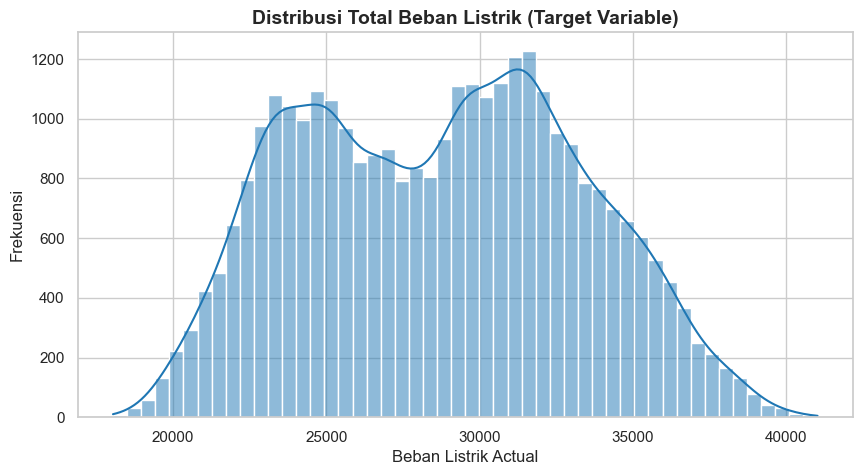

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['total load actual'], kde=True, color='#1f77b4', bins=50)
plt.title('Distribusi Total Beban Listrik (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Beban Listrik Actual', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

Distribusi total beban listrik pada grafik menunjukkan adanya dua pola konsumsi utama (bimodal), yang ditandai dengan dua puncak besar pada kisaran 24.000–25.000 dan 30.000–32.000. Hal ini mengindikasikan bahwa sistem listrik beroperasi dalam dua kondisi dominan, yaitu beban menengah yang merepresentasikan aktivitas normal dan beban tinggi yang kemungkinan terjadi pada jam sibuk (peak hours). Secara keseluruhan, mayoritas data berada pada rentang 24.000 hingga 33.000. Selain itu, sebaran data yang cukup luas menunjukkan bahwa beban listrik bersifat fluktuatif dan tidak konstan, yang mengindikasikan adanya pengaruh signifikan dari faktor waktu seperti jam, hari (weekday dan weekend), serta aktivitas manusia. Di sisi lain, nilai beban ekstrem, yaitu di bawah 20.000 dan di atas 38.000, relatif jarang terjadi dan dapat dikategorikan sebagai kondisi khusus atau outlier, yang mungkin disebabkan oleh hari libur besar, gangguan sistem, atau lonjakan kebutuhan listrik tertentu, sehingga penting untuk diperhatikan dalam konteks deteksi anomali dan perencanaan kapasitas.

### 3.2. Pola Konsumsi Listrik Berdasarkan Jam
Boxplot ini digunakan untuk melihat rentang beban listrik (nilai minimum, kuartil, median, maksimum) pada setiap jam dalam satu siklus harian (00:00 - 23:00).

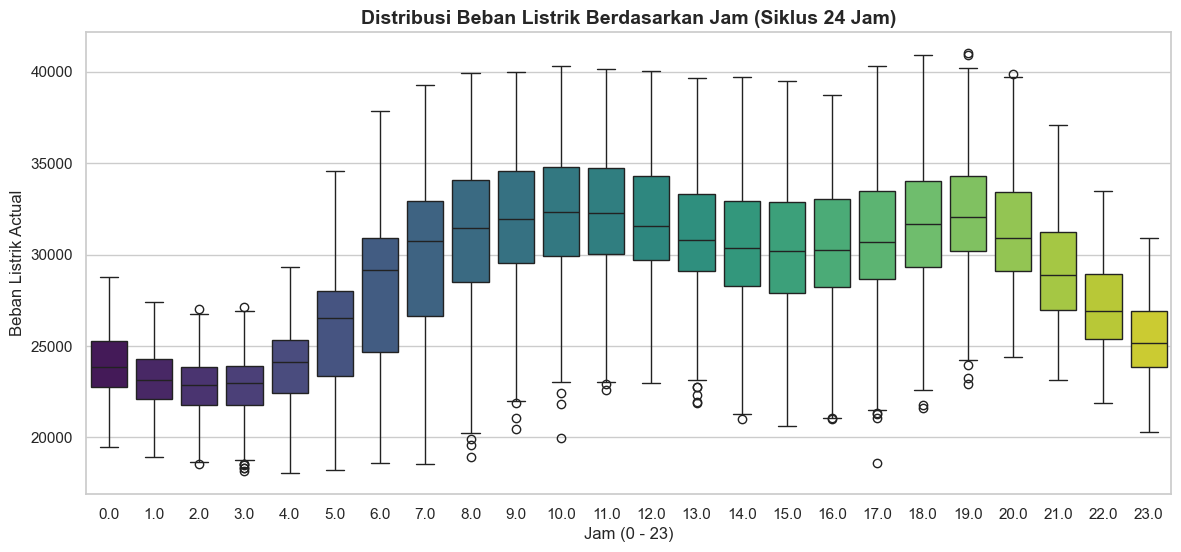

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_clean, x='hour', y='total load actual', palette='viridis')
plt.title('Distribusi Beban Listrik Berdasarkan Jam (Siklus 24 Jam)', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Beban Listrik Actual', fontsize=12)
plt.show()

Grafik distribusi beban listrik berdasarkan jam dalam siklus 24 jam menunjukkan pola variasi yang jelas sepanjang hari. Pada dini hari hingga pagi awal (sekitar pukul 00.00–04.00), beban listrik cenderung berada pada level rendah dan relatif stabil, yang mencerminkan minimnya aktivitas manusia pada waktu tersebut. Memasuki pagi hingga menjelang siang (sekitar pukul 05.00–10.00), terjadi peningkatan beban yang cukup signifikan, menandakan dimulainya aktivitas harian seperti operasional industri, perkantoran, dan rumah tangga. Beban listrik kemudian mencapai level tinggi dan relatif stabil pada rentang siang hingga sore (sekitar pukul 10.00–16.00), yang dapat dianggap sebagai periode beban puncak operasional.

Menjelang malam (sekitar pukul 17.00–20.00), beban listrik kembali menunjukkan peningkatan atau tetap tinggi, yang kemungkinan dipengaruhi oleh aktivitas rumah tangga setelah jam kerja, seperti penggunaan peralatan listrik secara bersamaan. Setelah itu, pada malam hari (sekitar pukul 21.00–23.00), beban listrik mulai menurun secara bertahap seiring berkurangnya aktivitas.
Kehadiran beberapa outlier di berbagai jam juga menandakan adanya kondisi ekstrem atau anomali yang perlu diperhatikan lebih lanjut dalam analisis maupun perencanaan sistem. Secara keseluruhan, grafik ini mengonfirmasi bahwa beban listrik sangat dipengaruhi oleh pola waktu harian, dengan karakteristik yang berbeda antara periode rendah, meningkat, puncak, dan penurunan.

### 3.3. Perbandingan Tren: Hari Kerja vs Akhir Pekan
Grafik garis (Lineplot) ini membandingkan rata-rata konsumsi listrik di setiap jamnya antara hari kerja (Senin-Jumat) dan hari libur/akhir pekan (Sabtu-Minggu).

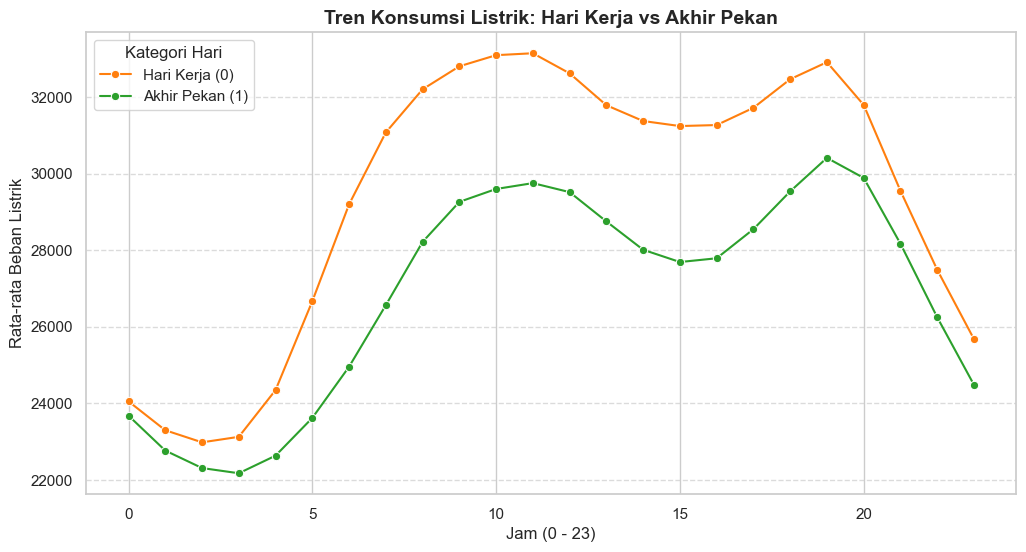

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_clean, x='hour', y='total load actual', hue='is_weekend', 
             marker='o', errorbar=None, palette=['#ff7f0e', '#2ca02c'])
plt.title('Tren Konsumsi Listrik: Hari Kerja vs Akhir Pekan', fontsize=14, fontweight='bold')
plt.xlabel('Jam (0 - 23)', fontsize=12)
plt.ylabel('Rata-rata Beban Listrik', fontsize=12)

plt.legend(title='Kategori Hari', labels=['Hari Kerja (0)', 'Akhir Pekan (1)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Grafik tren konsumsi listrik antara hari kerja dan akhir pekan menunjukkan perbedaan pola yang konsisten sepanjang siklus 24 jam. Secara umum, beban listrik pada hari kerja selalu lebih tinggi dibandingkan akhir pekan di hampir setiap jam, yang mengindikasikan bahwa aktivitas ekonomi seperti perkantoran dan industri memberikan kontribusi signifikan terhadap peningkatan konsumsi listrik. Pada dini hari hingga pagi awal (00.00–04.00), kedua kategori menunjukkan beban yang relatif rendah, namun hari kerja tetap sedikit lebih tinggi. Memasuki pagi (05.00–10.00), terjadi kenaikan tajam pada kedua pola, dengan lonjakan lebih signifikan pada hari kerja, mencerminkan dimulainya aktivitas operasional.

Pada periode siang hingga sore (sekitar 10.00–16.00), beban listrik hari kerja mencapai puncaknya dan cenderung stabil pada level tinggi, sementara akhir pekan juga meningkat namun tetap berada di bawahnya. Menariknya, pada malam hari (sekitar 18.00–20.00), kedua pola kembali mengalami peningkatan, yang menunjukkan adanya aktivitas rumah tangga yang dominan, meskipun selisih antara hari kerja dan akhir pekan mulai sedikit menyempit. Setelah pukul 21.00, beban listrik pada kedua kategori menurun secara bertahap seiring berkurangnya aktivitas.

Perbedaan yang konsisten ini menunjukkan bahwa faktor jenis hari (weekday vs weekend) merupakan variabel yang sangat berpengaruh terhadap pola konsumsi listrik. Pola ini memberikan implikasi praktis bagi pengelolaan energi, di mana strategi distribusi dan perencanaan kapasitas dapat disesuaikan antara hari kerja dan akhir pekan untuk mencapai efisiensi yang lebih optimal.

### 3.4. Analisis Korelasi Variabel (Heatmap)
Heatmap ini menampilkan korelasi terhadap target `total load actual`. Ini membantu kita memastikan apakah fitur yang kita buat (seperti Lag Features) benar-benar berdampak.

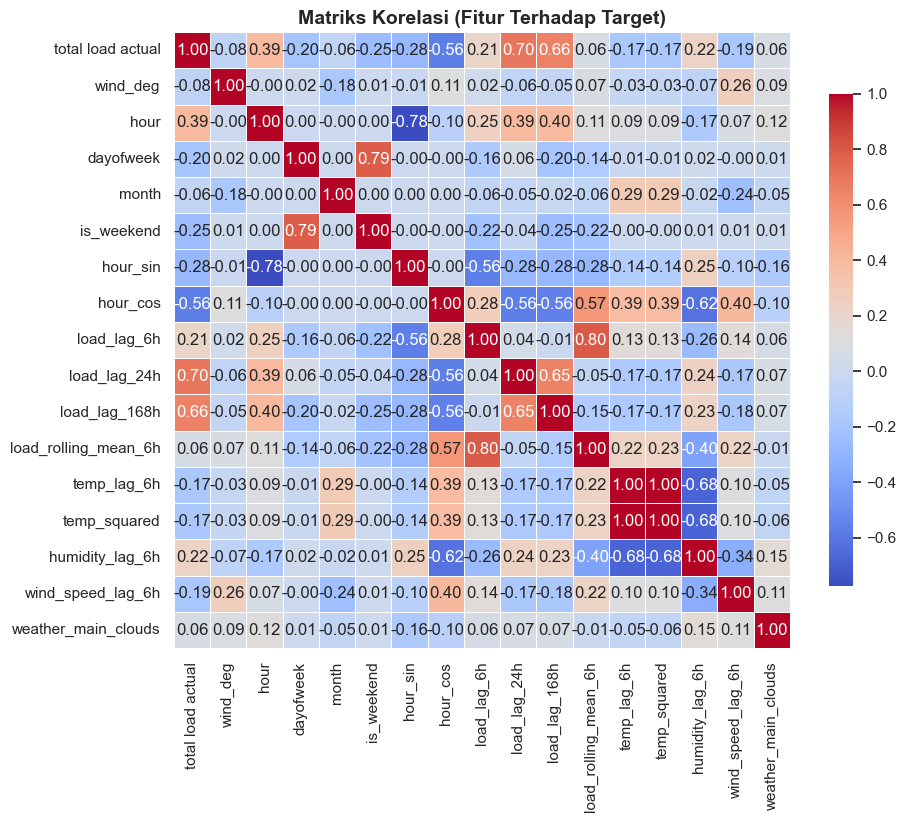

In [11]:
plt.figure(figsize=(10, 8))

# Menghitung korelasi seluruh variabel
corr_matrix = df_clean.corr()

top_corr_features = corr_matrix.index[abs(corr_matrix["total load actual"]) > 0.05]

# Membuat Heatmap
sns.heatmap(df_clean[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", 
            linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title('Matriks Korelasi (Fitur Terhadap Target)', fontsize=14, fontweight='bold')
plt.show()

Terlihat bahwa fitur berbasis historis (lag features) memiliki korelasi paling kuat terhadap target, khususnya load_lag_24h (≈0.70) dan load_lag_168h (≈0.66), yang mengindikasikan adanya pola musiman harian dan mingguan yang sangat dominan. Selain itu, hour juga memiliki korelasi positif moderat (≈0.39), menunjukkan bahwa waktu dalam sehari berpengaruh terhadap variasi beban, yang konsisten dengan pola siklus harian konsumsi listrik. 
Fitur transformasi siklikal seperti hour_cos menunjukkan korelasi negatif cukup kuat (≈-0.56), yang menegaskan bahwa pendekatan encoding siklus waktu (sin/cos) efektif dalam menangkap pola periodik. Sementara itu, fitur berbasis cuaca seperti suhu (temp_lag_6h, temp_squared) dan kelembapan (humidity_lag_6h) memiliki korelasi yang relatif lebih lemah hingga moderat terhadap target, menandakan bahwa faktor cuaca memang berpengaruh, tetapi tidak sekuat faktor historis beban. Variabel lain seperti wind speed dan weather_main_clouds menunjukkan korelasi yang rendah, sehingga kontribusinya terhadap prediksi kemungkinan kecil.

### 4. Data Splitting & Outlier Handling
Membagi data secara berurutan waktu (*chronological*) karena ini data *Time-Series*.
Dibuat 3 variasi skenario pembagian: 70:15:15, 80:10:10, dan 90:05:05.
Penanganan *Outlier* (nilai ekstrim) dilakukan setelah *split* dan dihitung HANYA dari data *Train*.

In [12]:
def triple_time_split(X, y, train_percent):
    remain_percent = (1.0 - train_percent) / 2
    train_idx = int(len(X) * train_percent)
    val_idx = int(len(X) * (train_percent + remain_percent))
    
    X_train, y_train = X.iloc[:train_idx].copy(), y.iloc[:train_idx].copy()
    X_val, y_val = X.iloc[train_idx:val_idx].copy(), y.iloc[train_idx:val_idx].copy()
    X_test, y_test = X.iloc[val_idx:].copy(), y.iloc[val_idx:].copy()
    
    # Penanganan Outlier (Zero Leakage)
    if 'pressure_lag_6h' in X_train.columns:
        median_pres_train = X_train['pressure_lag_6h'].median()
        for df_part in [X_train, X_val, X_test]:
            df_part.loc[(df_part['pressure_lag_6h'] > 1051) | (df_part['pressure_lag_6h'] < 931), 'pressure_lag_6h'] = median_pres_train

    return X_train, X_val, X_test, y_train, y_val, y_test

scenarios = {
    "Skenario A (70:15:15)": triple_time_split(X, y, 0.70),
    "Skenario B (80:10:10)": triple_time_split(X, y, 0.80),
    "Skenario C (90:05:05)": triple_time_split(X, y, 0.90)
}
print("✅ Splitting dan Outlier Handling selesai.")
print(" Splitting Time-Series 3 Skenario berhasil dibuat:")
for name, data in scenarios.items():
    print(f" - {name} -> Train: {len(data[0])} baris, Val: {len(data[1])} baris, Test: {len(data[2])} baris")

✅ Splitting dan Outlier Handling selesai.
 Splitting Time-Series 3 Skenario berhasil dibuat:
 - Skenario A (70:15:15) -> Train: 22323 baris, Val: 4784 baris, Test: 4784 baris
 - Skenario B (80:10:10) -> Train: 25512 baris, Val: 3189 baris, Test: 3190 baris
 - Skenario C (90:05:05) -> Train: 28701 baris, Val: 1595 baris, Test: 1595 baris


### 5. Model Building (Baseline Model)
Membangun 3 Algoritma berbeda (Random Forest, XGBoost, LightGBM) menggunakan nilai hyperparameter dasar (*default*) sebagai pembanding awal. Digunakan `Pipeline` untuk menyatukan proses standarisasi (Scaler).

In [21]:
# Pastikan fungsi perhitungan MAPE tersedia
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

baseline_models = {
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror'),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1)
}

baseline_results = []
print("Melatih Model Baseline (Default Parameters)...")

# Mengambil X_val dan y_val yang sebelumnya diabaikan dengan tanda '_'
for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    for model_name, model in baseline_models.items():
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        
        # Latih model menggunakan data Train
        pipe.fit(X_train, y_train)
        
        # Lakukan prediksi untuk ketiga pecahan data
        y_train_pred = pipe.predict(X_train)
        y_val_pred = pipe.predict(X_val)
        y_test_pred = pipe.predict(X_test)
        
        # Simpan seluruh metrik secara lengkap
        baseline_results.append({
            'Skenario': ratio_name,
            'Model': model_name,
            'Train R2': round(r2_score(y_train, y_train_pred), 4),
            'Val R2': round(r2_score(y_val, y_val_pred), 4),
            'Test R2': round(r2_score(y_test, y_test_pred), 4),
            'Test MAE': round(mean_absolute_error(y_test, y_test_pred), 2),
            'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2),
            'Test MAPE (%)': round(calculate_mape(y_test, y_test_pred), 2)
        })

# Tampilkan sebagai DataFrame yang rapi
df_baseline = pd.DataFrame(baseline_results)
display(df_baseline)

Melatih Model Baseline (Default Parameters)...


,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test RMSE,Test MAPE (%)
0,Skenario A (70:15:15),LightGBM,0.9234,0.8740,0.8897,1041.95,1499.42,3.67
1,Skenario A (70:15:15),XGBoost,0.9629,0.8767,0.8883,1026.25,1508.56,3.60
2,Skenario A (70:15:15),Random Forest,0.9872,0.8787,0.8864,1008.85,1521.84,3.54
3,Skenario B (80:10:10),LightGBM,0.9202,0.8761,0.8888,1007.12,1479.01,3.57
4,Skenario B (80:10:10),XGBoost,0.9593,0.8746,0.8936,959.11,1446.86,3.39
5,Skenario B (80:10:10),Random Forest,0.9872,0.8844,0.8875,938.80,1487.29,3.31
6,Skenario C (90:05:05),LightGBM,0.9180,0.8787,0.8910,1064.00,1493.76,3.73
7,Skenario C (90:05:05),XGBoost,0.9580,0.8829,0.9000,996.58,1430.60,3.50
8,Skenario C (90:05:05),Random Forest,0.9875,0.8833,0.8931,1009.11,1479.03,3.55


### 6. Hyperparameter Tuning (Optuna)
Melakukan proses tuning pada XGBoost dan LightGBM untuk mencari kombinasi parameter terbaik (`n_estimators`, `learning_rate`, `max_depth`, dll) yang mampu menekan nilai *error*.

In [14]:
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

tscv = TimeSeriesSplit(n_splits=3)
tuned_results = []

# Memasukkan Random Forest kembali ke dalam daftar model yang akan di-tune
models_to_tune = ['LightGBM', 'XGBoost', 'Random Forest']

print("⏳ Memulai Tuning dengan Optuna...\n")

for ratio_name, (X_train, X_val, X_test, y_train, y_val, y_test) in scenarios.items():
    print(f"=== Tuning Skenario: {ratio_name} ===")
    for model_name in models_to_tune:
        print(f"   Mencari parameter terbaik untuk {model_name}...")
        
        def objective(trial):
            if model_name == 'LightGBM':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 20, 100),
                    'max_depth': trial.suggest_int('max_depth', 4, 10),
                    'random_state': 42, 'n_jobs': -1, 'verbose': -1
                }
                model = LGBMRegressor(**params)
            elif model_name == 'XGBoost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 400),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                    'max_depth': trial.suggest_int('max_depth', 4, 8),
                    'subsample': trial.suggest_float('subsample', 0.7, 1.0),
                    'random_state': 42, 'n_jobs': -1, 'objective': 'reg:squarederror'
                }
                model = XGBRegressor(**params)
            else: # Logika Parameter untuk Random Forest
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 300),
                    'max_depth': trial.suggest_int('max_depth', 5, 15),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                    'random_state': 42, 'n_jobs': -1
                }
                model = RandomForestRegressor(**params)

            pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
            scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
            return scores.mean()

        sampler = optuna.samplers.TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)

        study.optimize(objective, n_trials=15) 
        
        best_params = study.best_params
        
        # Eksekusi Model Terbaik
        if model_name == 'LightGBM':
            best_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **best_params)
        elif model_name == 'XGBoost':
            best_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **best_params)
        else:
            best_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)

        best_pipeline = Pipeline([('scaler', StandardScaler()), ('model', best_model)])
        best_pipeline.fit(X_train, y_train)
        
        # Lakukan prediksi pada ketiga lapis data (Train, Val, Test)
        y_train_pred = best_pipeline.predict(X_train)
        y_val_pred = best_pipeline.predict(X_val)
        y_test_pred = best_pipeline.predict(X_test)
        
        # Simpan semua metrik secara lengkap (Termasuk Val R2)
        tuned_results.append({
            'Skenario': ratio_name, 'Model': model_name,
            'Train R2': round(r2_score(y_train, y_train_pred), 4),
            'Val R2': round(r2_score(y_val, y_val_pred), 4),
            'Test R2': round(r2_score(y_test, y_test_pred), 4),
            'Test MAE': round(mean_absolute_error(y_test, y_test_pred), 2),
            'Test RMSE': round(np.sqrt(mean_squared_error(y_test, y_test_pred)), 2),
            'Test MAPE (%)': round(calculate_mape(y_test, y_test_pred), 2),
            'Best Params': str(best_params)
        })

print("\n✅ Bayesian Optimization Selesai!")
df_tuned = pd.DataFrame(tuned_results)

⏳ Memulai Tuning dengan Optuna...

=== Tuning Skenario: Skenario A (70:15:15) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...
=== Tuning Skenario: Skenario B (80:10:10) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...
=== Tuning Skenario: Skenario C (90:05:05) ===
   Mencari parameter terbaik untuk LightGBM...
   Mencari parameter terbaik untuk XGBoost...
   Mencari parameter terbaik untuk Random Forest...

✅ Bayesian Optimization Selesai!


### 7 & 8. Model Evaluation & Comparison
Mengevaluasi hasil Tuning, membuat visualisasi komparasi (Barplot R2), melakukan skoring akhir, dan mengunci Model terbaik untuk divisualisasikan hasil peramalannya.

,Skenario,Model,Train R2,Val R2,Test R2,Test MAE,Test RMSE,Test MAPE (%),Best Params
0,Skenario A (70:15:15),LightGBM,0.9397,0.8783,0.8983,993.31,1440.07,3.50,"{'n_estimators': 212, 'learning_rate': 0.05786097596580467, 'num_leaves': 52, 'max_depth': 7}"
1,Skenario A (70:15:15),XGBoost,0.9372,0.8831,0.8968,1001.45,1450.61,3.53,"{'n_estimators': 384, 'learning_rate': 0.028825693577590687, 'max_depth': 6, 'subsample': 0.7053885626844459}"
2,Skenario A (70:15:15),Random Forest,0.9619,0.8761,0.8834,1035.51,1541.90,3.63,"{'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}"
3,Skenario B (80:10:10),LightGBM,0.9265,0.8802,0.8930,976.64,1450.82,3.46,"{'n_estimators': 155, 'learning_rate': 0.04265235498446136, 'num_leaves': 62, 'max_depth': 8}"
4,Skenario B (80:10:10),XGBoost,0.9346,0.8841,0.8956,967.13,1432.78,3.42,"{'n_estimators': 384, 'learning_rate': 0.028825693577590687, 'max_depth': 6, 'subsample': 0.7053885626844459}"
5,Skenario B (80:10:10),Random Forest,0.9604,0.8808,0.8848,968.12,1505.61,3.41,"{'n_estimators': 175, 'max_depth': 15, 'min_samples_split': 8}"
6,Skenario C (90:05:05),LightGBM,0.9348,0.8841,0.9018,993.75,1417.50,3.49,"{'n_estimators': 171, 'learning_rate': 0.03900730648793646, 'num_leaves': 95, 'max_depth': 8}"
7,Skenario C (90:05:05),XGBoost,0.9348,0.8854,0.9012,1008.82,1421.96,3.54,"{'n_estimators': 381, 'learning_rate': 0.03223498404215343, 'max_depth': 6, 'subsample': 0.7054367296359227}"
8,Skenario C (90:05:05),Random Forest,0.9597,0.8807,0.8897,1041.09,1502.64,3.65,"{'n_estimators': 171, 'max_depth': 15, 'min_samples_split': 8}"


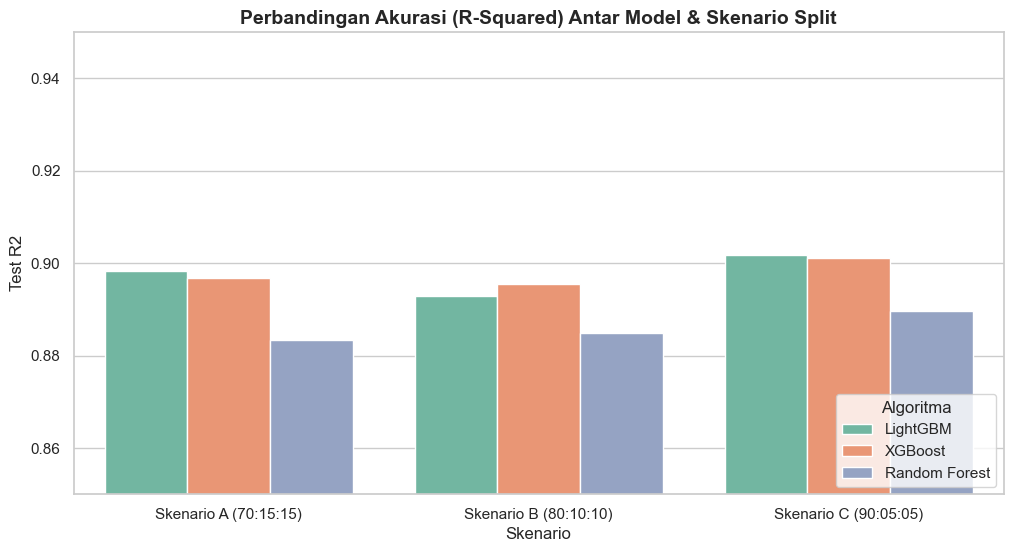

In [15]:
# ==========================================
# Model Evaluation
# ==========================================
display(df_tuned)

# =========================================================
# KOMPARASI & MULTI-METRIC SCORING
# =========================================================

# Visualisasi Komparasi Model
plt.figure(figsize=(12, 6))
sns.barplot(data=df_tuned, x='Skenario', y='Test R2', hue='Model', palette='Set2')
plt.title('Perbandingan Akurasi (R-Squared) Antar Model & Skenario Split', fontsize=14, fontweight='bold')
plt.ylim(0.85, 0.95) # Zoom agar perbedaan terlihat jelas
plt.legend(loc='lower right', title="Algoritma")
plt.show()

### 8. Seleksi Model Terbaik (Skoring Multimetrik)
Untuk menentukan model yang benar-benar terbaik, kita tidak hanya melihat Akurasi (R-Squared), tetapi juga memperhitungkan tingkat *Error* (MAE dan RMSE). 
Kita menggunakan pembobotan: **40% R2, 30% MAE, dan 30% RMSE** untuk menghasilkan skor akhir (`Final_Score`). Berikut adalah **Top 5 Model Terbaik** dari seluruh eksperimen:

In [16]:
# Skoring Multimetrik untuk mencari pemenang (Gabungan R2, MAE, dan RMSE)
df_rank = df_tuned.copy()

# Normalisasi Metrik (skala 0 - 1) agar bisa dijumlahkan
df_rank['R2_Norm'] = (df_rank['Test R2'] - df_rank['Test R2'].min()) / (df_rank['Test R2'].max() - df_rank['Test R2'].min())
df_rank['MAE_Norm'] = (df_rank['Test MAE'].max() - df_rank['Test MAE']) / (df_rank['Test MAE'].max() - df_rank['Test MAE'].min())
df_rank['RMSE_Norm'] = (df_rank['Test RMSE'].max() - df_rank['Test RMSE']) / (df_rank['Test RMSE'].max() - df_rank['Test RMSE'].min())

# Menghitung Final Score dengan Bobot
df_rank['Final_Score'] = (df_rank['R2_Norm'] * 0.4) + (df_rank['MAE_Norm'] * 0.3) + (df_rank['RMSE_Norm'] * 0.3)
df_rank = df_rank.sort_values(by='Final_Score', ascending=False).reset_index(drop=True)

# Menampilkan Top 5 Model Terbaik
print("🏆 KLASEMEN 5 MODEL TERBAIK 🏆")
display(df_rank[['Skenario', 'Model', 'Test R2', 'Test MAPE (%)', 'Final_Score']].head(5))

🏆 KLASEMEN 5 MODEL TERBAIK 🏆


,Skenario,Model,Test R2,Test MAPE (%),Final_Score
0,Skenario C (90:05:05),LightGBM,0.9018,3.49,0.892023
1,Skenario B (80:10:10),XGBoost,0.8956,3.42,0.828369
2,Skenario C (90:05:05),XGBoost,0.9012,3.54,0.807096
3,Skenario A (70:15:15),LightGBM,0.8983,3.50,0.763291
4,Skenario B (80:10:10),LightGBM,0.8930,3.46,0.689767


### 9. Final Validation (Uji Kelayakan Model Juara)
Model yang menduduki Peringkat 1 akan dikunci (*lock*) parameter dan skenarionya. Model ini kemudian dilatih ulang menggunakan Data Testing.
Dua visualisasi di bawah ini membuktikan seberapa presisi prediksi model dibandingkan dengan kenyataan di lapangan.

🚀 Mempersiapkan Model Final: LightGBM pada Skenario C (90:05:05)...


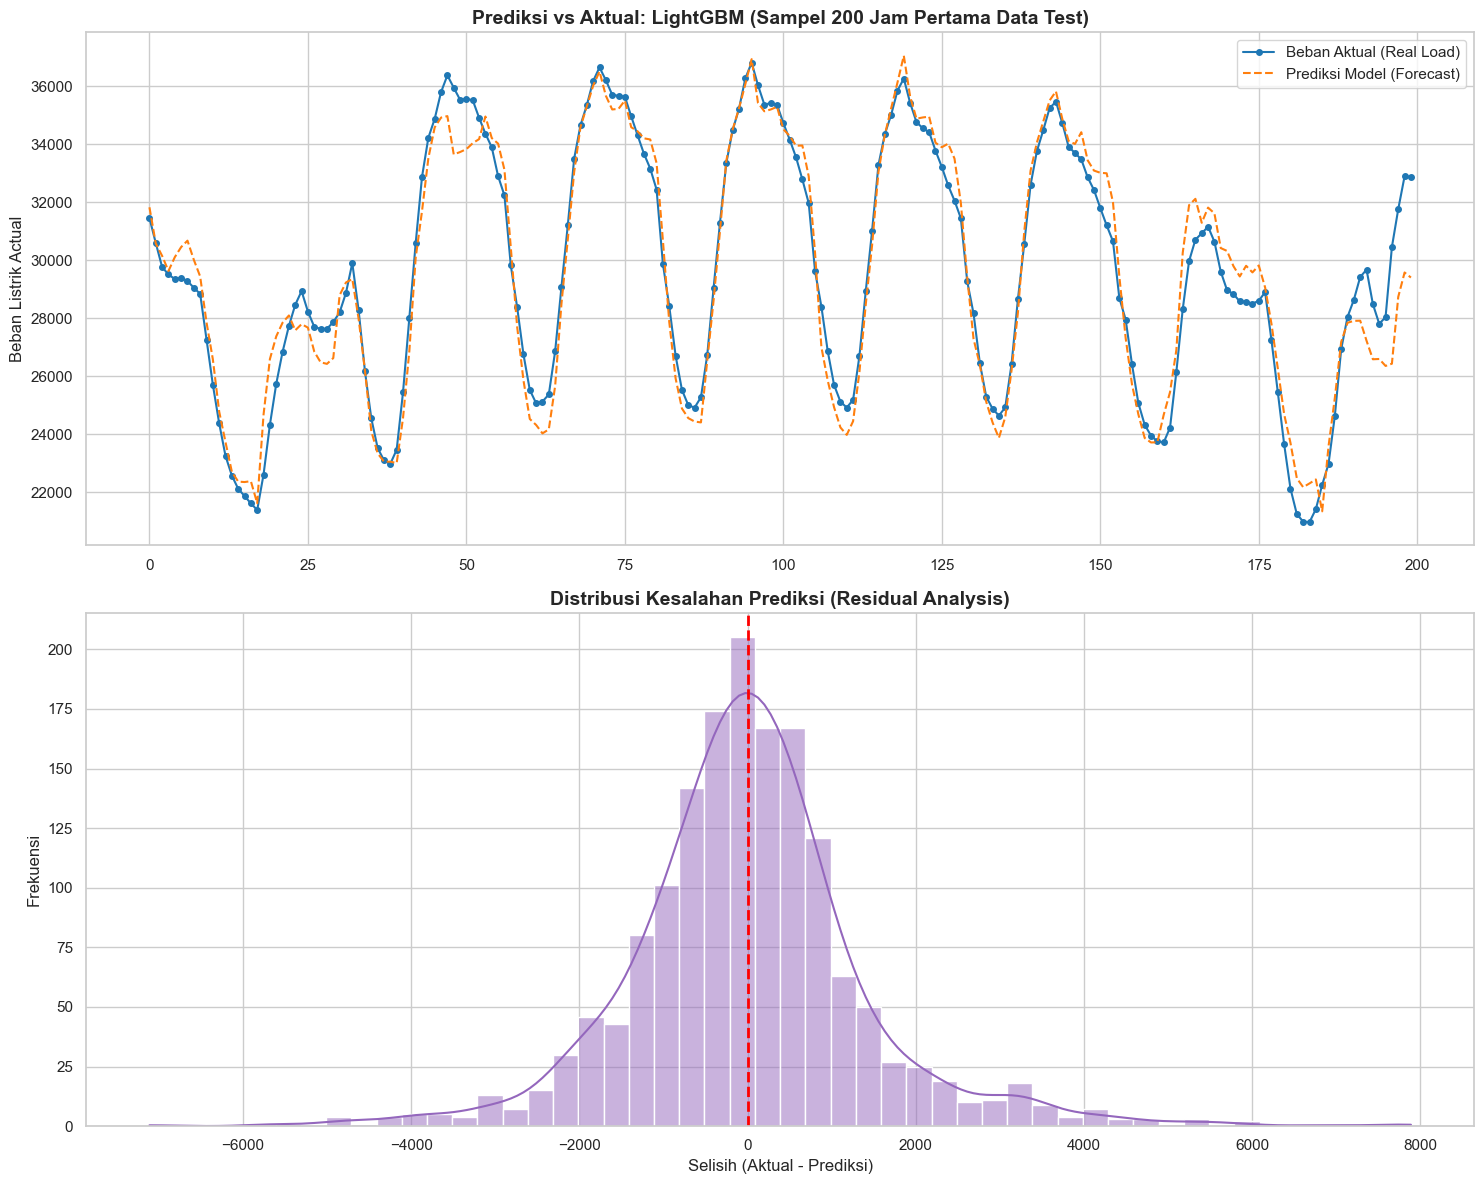

In [17]:
# Mengambil Identitas Sang Juara (Peringkat 1)
best_scenario = df_rank.loc[0, 'Skenario']
best_model_name = df_rank.loc[0, 'Model']
best_params_str = df_rank.loc[0, 'Best Params']

print(f"🚀 Mempersiapkan Model Final: {best_model_name} pada {best_scenario}...")

# Ekstraksi Data sesuai Skenario Pemenang
X_final_train, X_final_val, X_final_test, y_final_train, y_final_val, y_final_test = scenarios[best_scenario]
params_dict = ast.literal_eval(best_params_str)

# Inisialisasi Model terbaik
if best_model_name == 'LightGBM':
    base_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1, **params_dict)
elif best_model_name == 'XGBoost':
    base_model = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror', **params_dict)
else:
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1, **params_dict)

# Latih dan Prediksi
final_pipeline = Pipeline([('scaler', StandardScaler()), ('model', base_model)])
final_pipeline.fit(X_final_train, y_final_train)
y_final_pred = final_pipeline.predict(X_final_test)

# --- VISUALISASI UJI KELAYAKAN ---
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Grafik Aktual vs Prediksi
axes[0].plot(y_final_test.values[:200], label='Beban Aktual (Real Load)', color='#1f77b4', marker='o', markersize=4)
axes[0].plot(y_final_pred[:200], label='Prediksi Model (Forecast)', color='#ff7f0e', linestyle='--')
axes[0].set_title(f'Prediksi vs Aktual: {best_model_name} (Sampel 200 Jam Pertama Data Test)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Beban Listrik Actual', fontsize=12)
axes[0].legend()

# 2. Grafik Distribusi Residual (Error)
sns.histplot(y_final_test - y_final_pred, kde=True, ax=axes[1], color='#9467bd', bins=50)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribusi Kesalahan Prediksi (Residual Analysis)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Selisih (Aktual - Prediksi)', fontsize=12)
axes[1].set_ylabel('Frekuensi', fontsize=12)

plt.tight_layout()
plt.show()

### 10. Kesimpulan Akhir
Berdasarkan seluruh proses *Machine Learning* mulai dari *Preprocessing*, *Tuning*, hingga Evaluasi, berikut adalah ringkasan performa model yang telah memenuhi kriteria dan siap untuk diimplementasikan (*Deployment*).

In [18]:
print("=========================================================")
print("             KESIMPULAN FINAL PROJECT                    ")
print("=========================================================")
print(f"1. Model Terpilih : {best_model_name}")
print(f"2. Skenario Split : {best_scenario}")
print(f"3. R-Squared (R2) : {r2_score(y_final_test, y_final_pred):.4f} (Akurasi R²)")
print(f"4. MAPE Score     : {calculate_mape(y_final_test, y_final_pred):.2f}% (Rata-rata Margin Error)")
print("---------------------------------------------------------")

             KESIMPULAN FINAL PROJECT                    
1. Model Terpilih : LightGBM
2. Skenario Split : Skenario C (90:05:05)
3. R-Squared (R2) : 0.9018 (Akurasi R²)
4. MAPE Score     : 3.49% (Rata-rata Margin Error)
---------------------------------------------------------


### 11. Pengujian Data Unseen & Penyimpanan Model (Deployment Prep)
Tahap ini menguji ketangguhan model menggunakan dataset yang benar-benar baru (`energy_dataset_test.csv` dan `weather_features_test.csv`). 

Digunakan **"Teknik Jembatan"**, yaitu mengambil 168 jam terakhir dari data latih untuk disambungkan ke data baru. Ini dilakukan agar model tetap memiliki memori masa lalu untuk memprediksi jam-jam awal di data baru. Terakhir, model yang lulus uji akan disimpan (Export) menggunakan `joblib` agar siap digunakan pada sistem *Inference*.

✅ Data Unseen berhasil diproses. Siap diuji: 2999 baris.
🚀 Model yang diuji : LightGBM - Skenario C (90:05:05)

📊 HASIL UJIAN (UNSEEN DATA) 📊
---------------------------------------------------------
R-Squared (R2) : 0.8942
MAE            : 1033.27 MW
RMSE           : 1511.31 MW
MAPE Score     : 3.67%
---------------------------------------------------------
💡 KESIMPULAN: LULUS! Model sangat stabil dan tidak mengalami Overfitting.

💾 Model berhasil disimpan sebagai: 'best_forecasting_model.pkl'
💾 Daftar fitur berhasil disimpan sebagai: 'model_features.pkl'


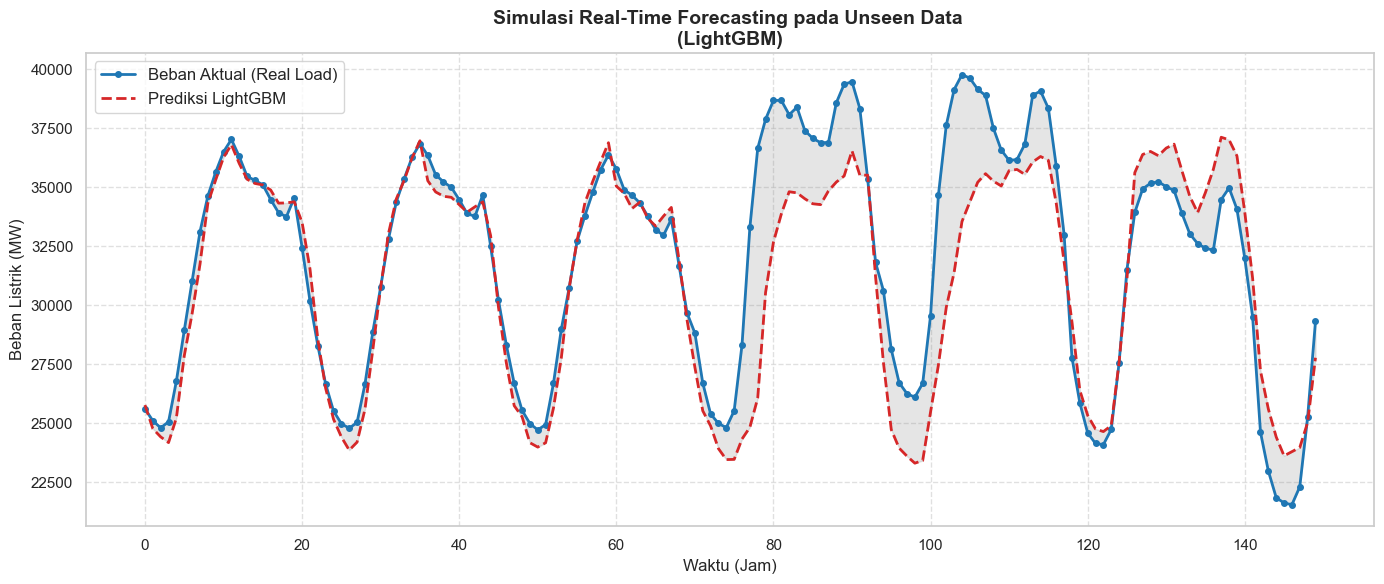

In [19]:
# 1. LOAD DATA BARU (UNSEEN DATA)
file_energy_baru = 'energy_dataset_test.csv' 
file_weather_baru = 'weather_features_test.csv'

try:
    df_energy_new = pd.read_csv(file_energy_baru)
    df_weather_new = pd.read_csv(file_weather_baru)
    
    # Samakan format waktu (Hapus UTC)
    df_energy_new['time'] = pd.to_datetime(df_energy_new['time'], utc=True).dt.tz_localize(None)
    df_weather_new['time'] = pd.to_datetime(df_weather_new['time'], utc=True).dt.tz_localize(None)
    
    # Hapus data leakage jika ada di data test
    df_energy_new = df_energy_new.drop(columns=[col for col in leakage_and_useless_cols if col in df_energy_new.columns])
    
    # Gabungkan data baru
    df_new_merged = pd.merge(df_energy_new, df_weather_new, on='time', how='inner')
    
    # ---------------------------------------------------------
    # 2. TEKNIK JEMBATAN (THE BRIDGE) - MENCEGAH NAN AWAL
    # ---------------------------------------------------------
    # Mengambil 168 baris terakhir dari data asli (df) di Cell 2 sbg jembatan masa lalu
    bridge_data = df.tail(168).copy()
    
    # Sambungkan jembatan dengan data baru
    df_combined = pd.concat([bridge_data, df_new_merged], axis=0, ignore_index=True)
    
    # 3. PREPROCESSING (Otomatis membuang baris jembatan setelah fitur Lag terbentuk)
    df_test_ready = preprocess_time_series(df_combined)
    
    print(f"✅ Data Unseen berhasil diproses. Siap diuji: {df_test_ready.shape[0]} baris.")
    print(f"🚀 Model yang diuji : {best_model_name} - {best_scenario}\n")
    
    # 4. PENYIAPAN PREDIKTOR & TARGET
    X_unseen = df_test_ready.drop(columns=['total load actual'])
    y_unseen = df_test_ready['total load actual']
    
    # Mencegah Error Kolom Kategorikal Cuaca (One-Hot Encoding)
    X_unseen = X_unseen.reindex(columns=X_final_train.columns, fill_value=0)
    
    # 5. PREDIKSI (Langsung menggunakan final_pipeline karena Scaler sudah di dalamnya)
    y_unseen_pred = final_pipeline.predict(X_unseen)
    
    # 6. EVALUASI METRIK PADA DATA UNSEEN
    r2_unseen = r2_score(y_unseen, y_unseen_pred)
    mae_unseen = mean_absolute_error(y_unseen, y_unseen_pred)
    rmse_unseen = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
    mape_unseen = calculate_mape(y_unseen, y_unseen_pred)

    print("📊 HASIL UJIAN (UNSEEN DATA) 📊")
    print("---------------------------------------------------------")
    print(f"R-Squared (R2) : {r2_unseen:.4f}")
    print(f"MAE            : {mae_unseen:.2f} MW")
    print(f"RMSE           : {rmse_unseen:.2f} MW")
    print(f"MAPE Score     : {mape_unseen:.2f}%")
    print("---------------------------------------------------------")
    
    if r2_unseen >= 0.85:
        print("💡 KESIMPULAN: LULUS! Model sangat stabil dan tidak mengalami Overfitting.")
    else:
        print("⚠️ KESIMPULAN: WASPADA! Model mengalami penurunan performa di data baru.")

    # 7. MENYIMPAN MODEL & FITUR KE FILE .PKL
    model_filename = 'best_forecasting_model.pkl'
    features_filename = 'model_features.pkl'
    
    joblib.dump(final_pipeline, model_filename)
    joblib.dump(X_final_train.columns.tolist(), features_filename)
    print(f"\n💾 Model berhasil disimpan sebagai: '{model_filename}'")
    print(f"💾 Daftar fitur berhasil disimpan sebagai: '{features_filename}'")

    # 8. VISUALISASI AKTUAL VS PREDIKSI
    plt.figure(figsize=(14, 6))
    sample_limit = 150
    plt.plot(y_unseen.values[:sample_limit], label='Beban Aktual (Real Load)', marker='o', markersize=4, color='#1f77b4', linewidth=2)
    plt.plot(y_unseen_pred[:sample_limit], label=f'Prediksi {best_model_name}', linestyle='--', color='#d62728', linewidth=2)
    
    plt.title(f'Simulasi Real-Time Forecasting pada Unseen Data \n({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Jam)', fontsize=12)
    plt.ylabel('Beban Listrik (MW)', fontsize=12)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.fill_between(range(len(y_unseen.values[:sample_limit])), 
                     y_unseen.values[:sample_limit], 
                     y_unseen_pred[:sample_limit], 
                     color='gray', alpha=0.2, label='Selisih (Error)')
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("❌ ERROR: File data testing baru tidak ditemukan.")
    print("Pastikan 'energy_dataset_test.csv' dan 'weather_features_test.csv' ada di folder yang sama dengan Jupyter Notebook ini.")